In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

print("Biblioteca + Definição padrão dos Gráficos")


Biblioteca + Definição padrão dos Gráficos


In [2]:

df_orders = pd.read_csv(r'C:\Users\Mateus Fernandes\Documents\olist-analytics\data\raw\olist_orders_dataset.csv')
df_order_items = pd.read_csv(r'C:\Users\Mateus Fernandes\Documents\olist-analytics\data\raw\olist_order_items_dataset.csv')
df_products = pd.read_csv(r'C:\Users\Mateus Fernandes\Documents\olist-analytics\data\raw\olist_products_dataset.csv')

print("Dados carregados!!!")

# Converter datas para datetime
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['order_delivered_customer_date'] = pd.to_datetime(df_orders['order_delivered_customer_date'])

# Calcular delivery_time
df_orders['delivery_time'] = (df_orders['order_delivered_customer_date'] - df_orders['order_purchase_timestamp']).dt.days

print(f"Total de pedidos: {len(df_orders)}")
print(f"Total de itens: {len(df_order_items)}")
print(f"Total de produtos: {len(df_products)}")

Dados carregados!!!
Total de pedidos: 99441
Total de itens: 112650
Total de produtos: 32951


In [3]:
import os
os.makedirs('assets', exist_ok=True)
print("Pasta 'assets' criada na pasta atual!")

# Verificar se foi criada
print(os.listdir('.'))

Pasta 'assets' criada na pasta atual!
['.git', '.gitignore', '.ipynb_checkpoints', '02_data_cleaning.ipynb', '03_visualization.ipynb', 'assets', 'data', 'notebooks', 'README.md', 'src', 'venv']


In [4]:
# Juntar as tabelas para saber quantos itens foram vendidos por categoria
df_items_products = df_order_items.merge(df_products, on='product_id')

# Contar quantos itens foram vendidos por categoria
categoria_mais_vendidas = df_items_products['product_category_name'].value_counts().head(10)

# Criar um DataFrame para visualização
df_top_categorias = categoria_mais_vendidas.reset_index()
df_top_categorias.columns = ['categoria', 'quantidade']

print("Top 10 categorias mais vendidas:")
print(df_top_categorias)

Top 10 categorias mais vendidas:
                categoria  quantidade
0         cama_mesa_banho       11115
1            beleza_saude        9670
2           esporte_lazer        8641
3        moveis_decoracao        8334
4  informatica_acessorios        7827
5   utilidades_domesticas        6964
6      relogios_presentes        5991
7               telefonia        4545
8      ferramentas_jardim        4347
9              automotivo        4235


C:\Users\Mateus Fernandes\AppData\Local\Temp\ipykernel_16872\2274432604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='quantidade', y='categoria', data=df_top_categorias, palette='viridis')


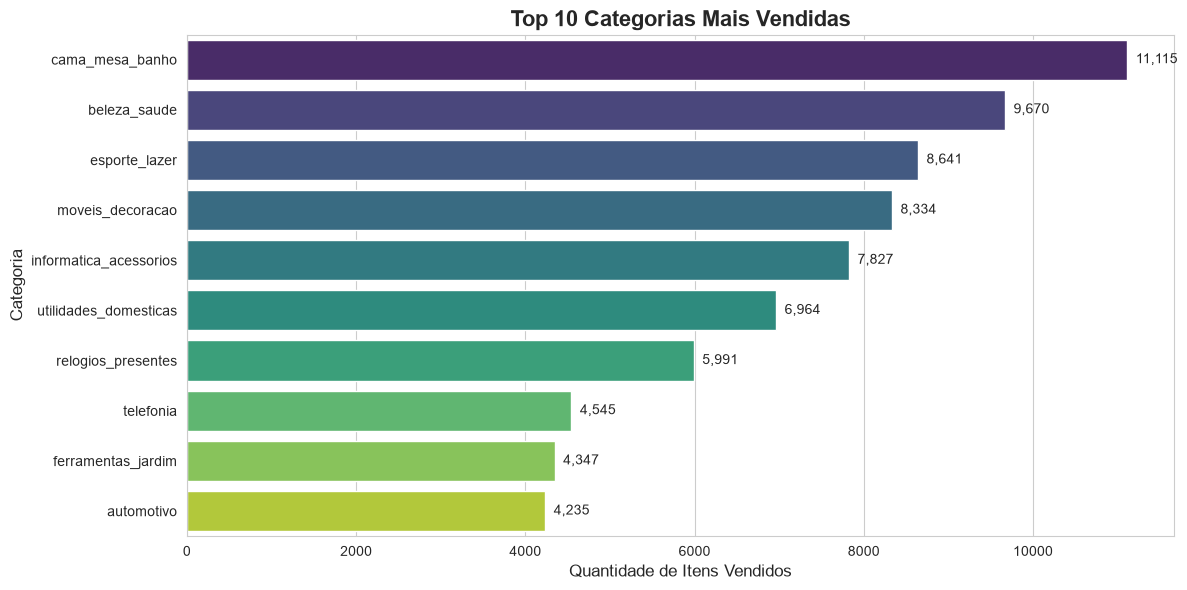

In [5]:
# Criar o gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(x='quantidade', y='categoria', data=df_top_categorias, palette='viridis')
plt.title('Top 10 Categorias Mais Vendidas', fontsize=16, fontweight='bold')
plt.xlabel('Quantidade de Itens Vendidos', fontsize=12)
plt.ylabel('Categoria', fontsize=12)

# Adicionar os valores nas barras
for i, valor in enumerate(df_top_categorias['quantidade']):
    plt.text(valor + 100, i, f'{valor:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('assets/categorias_mais_vendidas.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
import os
print(os.listdir('assets'))

['categorias_mais_vendidas.png']


In [7]:
# Remover valores nulos de delivery_time
df_delivery = df_orders['delivery_time'].dropna()

print(f"Total de pedidos com tempo de entrega: {len(df_delivery)}")
print(f"Tempo médio: {df_delivery.mean():.2f} dias")
print(f"Tempo máximo: {df_delivery.max():.0f} dias")
print(f"Tempo mínimo: {df_delivery.min():.0f} dias")

Total de pedidos com tempo de entrega: 96476
Tempo médio: 12.09 dias
Tempo máximo: 209 dias
Tempo mínimo: 0 dias


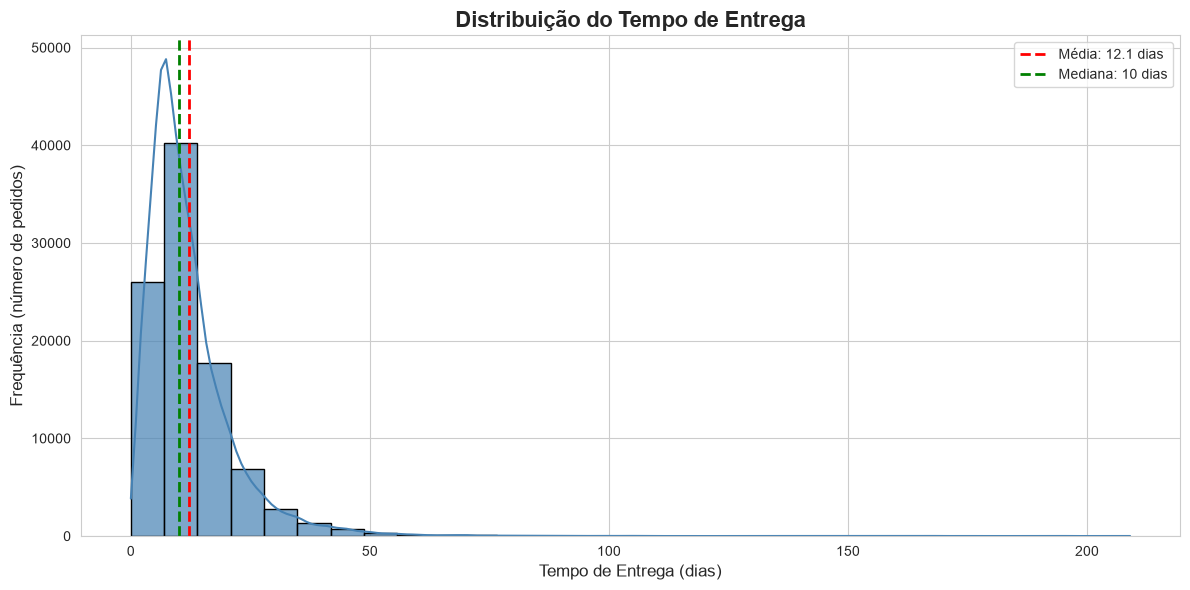

In [8]:
# Criar histograma com Seaborn
plt.figure(figsize=(12, 6))

sns.histplot(df_delivery, bins=30, kde=True, color='steelblue', edgecolor='black', alpha=0.7)

plt.title('Distribuição do Tempo de Entrega', fontsize=16, fontweight='bold')
plt.xlabel('Tempo de Entrega (dias)', fontsize=12)
plt.ylabel('Frequência (número de pedidos)', fontsize=12)

media = df_delivery.mean()
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Média: {media:.1f} dias')

mediana = df_delivery.median()
plt.axvline(mediana, color='green', linestyle='--', linewidth=2, label=f'Mediana: {mediana:.0f} dias')

plt.legend()
plt.tight_layout()
plt.savefig('assets/distribuicao_tempo_entrega.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Pegar as 10 categorias mais vendidas
top_categorias = df_top_categorias['categoria'].tolist()

# Filtrar os itens apenas dessas categorias
df_itens_top = df_items_products[df_items_products['product_category_name'].isin(top_categorias)]

print(f"Total de itens nas top 10 categorias: {len(df_itens_top)}")

Total de itens nas top 10 categorias: 71669


C:\Users\Mateus Fernandes\AppData\Local\Temp\ipykernel_16872\336257979.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='product_category_name', y='price', data=df_itens_top, palette='Set3')


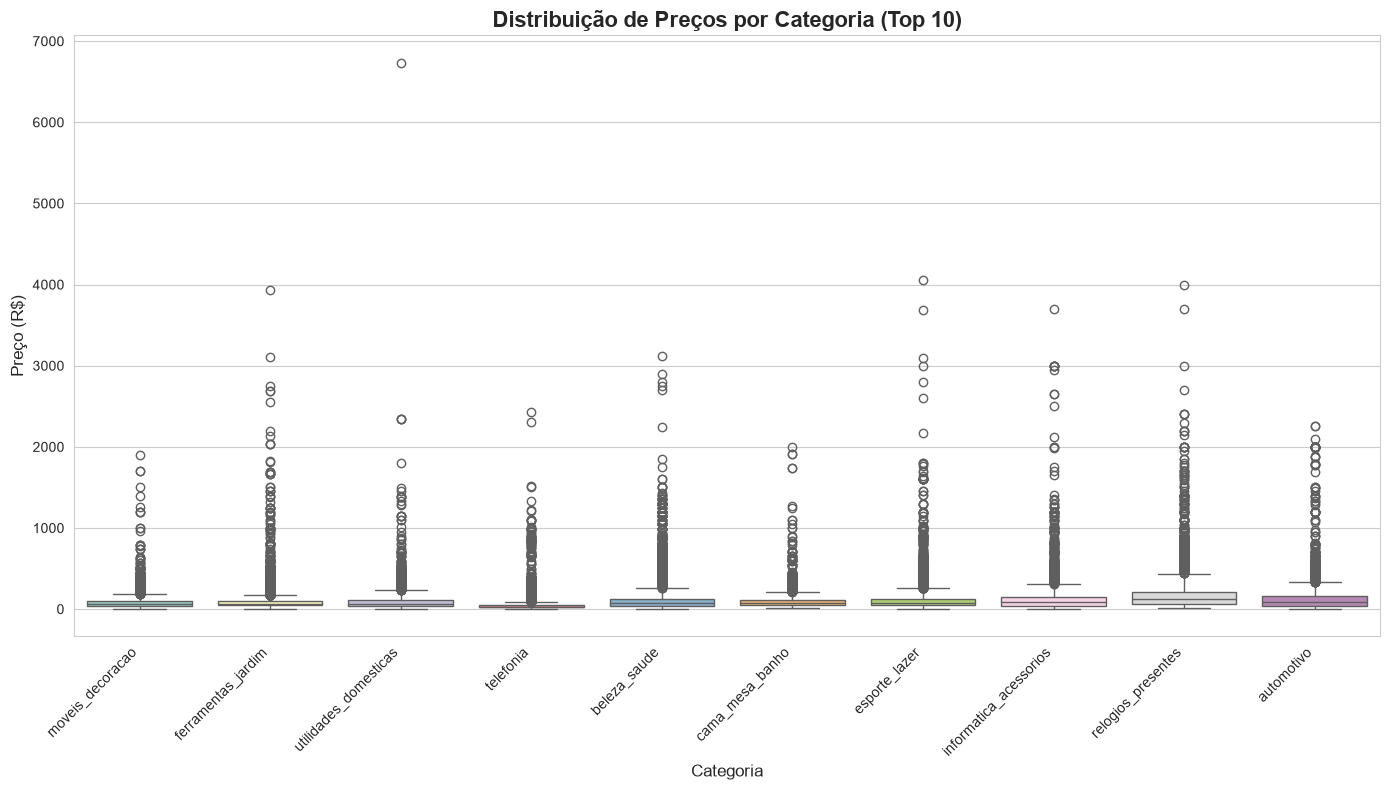

In [10]:
# Criar Boxplot
plt.figure(figsize=(14, 8))

sns.boxplot(x='product_category_name', y='price', data=df_itens_top, palette='Set3')

plt.title('Distribuição de Preços por Categoria (Top 10)', fontsize=16, fontweight='bold')
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Preço (R$)', fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.savefig('assets/boxplot_precos_categorias.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
print(os.listdir('assets'))

['boxplot_precos_categorias.png', 'categorias_mais_vendidas.png', 'distribuicao_tempo_entrega.png']


##  Insights da Análise Visual

### 1. Categorias Mais Vendidas
- **Beleza e Saúde** e **Relógios/Presentes** lideram em quantidade de vendas
- Categorias de consumo pessoal e decoração dominam o marketplace

### 2. Tempo de Entrega
- **Média**: ~12 dias
- **Mediana**: 10 dias
- A maioria dos pedidos é entregue entre 6 e 15 dias
- Poucos pedidos demoram mais de 30 dias

### 3. Preços por Categoria
- Grandes variações de preço dentro de cada categoria
- Categorias como "relogios_presentes" têm outliers (produtos muito caros)
- "beleza_saude" tem uma distribuição mais concentrada de preços